In [1]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import matplotlib.pyplot as plt
import pandas
%load_ext autoreload
%autoreload 1

In [2]:
%aimport crossmatching
from crossmatching import Crossmatcher

In [3]:
cm = Crossmatcher()

input = ascii.read("./input/HPIC_LC4_combined_d50.txt")

cm.load_alternate_ids(input["star_name"], from_file="alternate_ids.txt")
cm.load_catalog(from_file="pscomppars.txt")

matched = cm.combined_crossmatch(input)
matched["star_name", "pl_name", "match_type", "pl_radj"].pprint()

  star_name     pl_name    match_type  pl_radj  
------------- ------------ ---------- ----------
 TIC 18097734  HD 168746 b         id      0.993
TIC 232606278  HD 156279 b         id       1.12
TIC 232606278  HD 156279 c         id       1.11
TIC 450102450     GJ 179 b         id       1.23
TIC 139754153     GJ 832 b         id       1.23
 TIC 61397572  HD 134987 c         id       1.24
 TIC 49324530  HIP 79431 b         id       1.19
TIC 188580272     GJ 876 b         id       1.19
TIC 292113181  HD 114783 c         id        1.2
TIC 292113181  HD 114783 b         id       1.23
          ...          ...        ...        ...
TIC 217831699 BD-11 4672 c         2d       0.36
TIC 377293776 TOI-1450 A b         2d 0.10081202
TIC 187278212   Wolf 503 b         2d 0.18226457
TIC 101418130   HD 86065 b         2d       1.12
TIC 406095880     PZ Tel b         2d       1.07
TIC 115319029   HD 11112 b         2d       1.12
TIC 328159699   HD 11505 b         2d       1.12
  TIC 7244844   HD 1

Counter({np.str_('id'): 477, np.str_('2d'): 293, np.str_('3d'): 82})

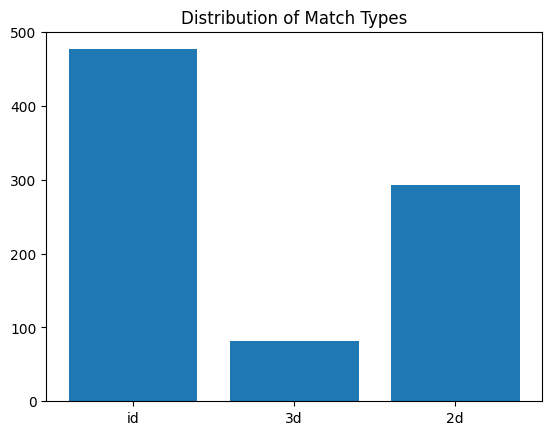

In [ ]:
ctr = Counter(matched["match_type"])
plt.title("Distribution of Match Types")
plt.bar(ctr.keys(), ctr.values())
ctr

The Duplicates Problem

In [5]:
final = cm.combined_crossmatch(input)
print("method\t", "# matches", "# unique planet names", sep="\t")
print("id", len(cm.id_matched), len(set(cm.id_matched["pl_name"])), sep="\t\t")
print("3d", len(cm.coords3d_matched), len(set(cm.coords3d_matched["pl_name"])), sep="\t\t")
print("2d", len(cm.coords2d_matched), len(set(cm.coords2d_matched["pl_name"])), sep="\t\t")
print("cmb", len(final), len(set(final["pl_name"])), sep="\t\t") # this shouldn't happen
final["star_name", "hostname", "id", "match_type"][np.isin(final["pl_name"], ["HD 46375 b", "DS Tuc A b",  "GJ 887 b", "GJ 887 c", "GJ 887 d"])]

method		# matches	# unique planet names
id		477		473
3d		184		184
2d		727		727
cmb		852		848


star_name,hostname,id,match_type
str29,str27,str23,str2
TIC 471015557,GJ 887,GJ 887,id
TIC 155315739,GJ 887,GJ 887,id
TIC 471015557,GJ 887,GJ 887,id
TIC 155315739,GJ 887,GJ 887,id
TIC 471015557,GJ 887,GJ 887,id
TIC 155315739,GJ 887,GJ 887,id
TIC 234928947,HD 46375,--,2d
TIC 410214986,DS Tuc A,--,2d


In [6]:
# find the entries in the final table where the "pl_name" key is not unique:
vals, inverse, counts = np.unique(final['pl_name'], return_inverse=True, return_counts=True)

# 2. Find which *indices* of the unique array belong to duplicates
# counts > 1 creates a boolean mask for the 'vals' array
duplicate_mask_in_unique = counts > 1
# 3. Map that mask back to the original array's length using 'inverse'
is_duplicate = duplicate_mask_in_unique[inverse]
# 4. Pull the rows from the original array
non_unique_rows = final[is_duplicate]
non_unique_rows["pl_name", "star_name", "hostname", "id", "match_type"]

# so our duplicates algorithm should at least match
# TIC 471015557 <-> TIC 155315739


pl_name,star_name,hostname,id,match_type
str29,str29,str27,str23,str2
GJ 887 b,TIC 471015557,GJ 887,GJ 887,id
GJ 887 b,TIC 155315739,GJ 887,GJ 887,id
GJ 887 c,TIC 471015557,GJ 887,GJ 887,id
GJ 887 c,TIC 155315739,GJ 887,GJ 887,id
GJ 887 d,TIC 471015557,GJ 887,GJ 887,id
GJ 887 d,TIC 155315739,GJ 887,GJ 887,id
GJ 887 e,TIC 471015557,GJ 887,GJ 887,id
GJ 887 e,TIC 155315739,GJ 887,GJ 887,id


In [7]:
Table.read()
Table.read(
"""
star_name|sy_dist|st_spectype|st_rad|st_teff|st_mass|st_age|ra|dec|sy_vmag|sy_jmag|sy_hmag|sy_kmag|known_binary_fl|gaia_binary_fl|WDSsep|wds_deltamag
TIC 179323446|18.034265103697024|K0-IIIb|95.04294561366169|4924.0|0.8081666320131379|null|211.670609|-36.369934|null|null|null|null|1|0|3.0|11.84
TIC 471015557||null||3676.3||null|346.4668|-35.8531|null|null|null|null|0|0|null|null
"""
)

IndexError: tuple index out of range